In [3]:
import numpy as np
import matplotlib.pyplot as plt
from torch import nn,optim
from torch.autograd import Variable
import torch

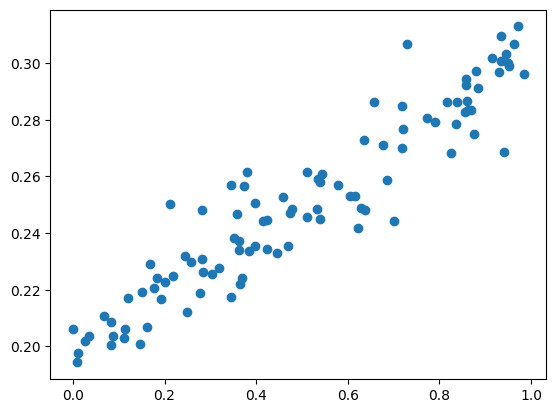

In [5]:
x_data = np.random.rand(100)
noise = np.random.normal(0,0.01,x_data.shape)
y_data = x_data*0.1+0.2+noise

plt.scatter(x_data,y_data)
plt.show()

In [6]:
x_data = x_data.reshape(-1,1)
y_data = y_data.reshape(-1,1)

In [7]:
#把numpy数据变为tensor
x_data = torch.FloatTensor(x_data)
y_data = torch.FloatTensor(y_data)
inputs = Variable(x_data)
target = Variable(y_data)

In [8]:
#构建神经网络模型
#一般把网络中具有可学习参数的层放在__init__()中
class LinearRegression(nn.Module):
    #定义网络结构
    def __init__(self):
        #初始化nn.moudle
        super(LinearRegression,self).__init__()
        self.fc = nn.Linear(1,1)
    #定义网络计算
    def forward(self,x):
        out = self.fc(x)
        return out

In [14]:
#定义模型
model = LinearRegression()
#定义代价函数
mes_loss = nn.MSELoss()
#定义优化器
optimizer = optim.SGD(model.parameters(), lr = 0.1)

In [15]:
for name, parameters in model.named_parameters():
    print('name:{}, param:{}'.format(name,parameters))

name:fc.weight, param:Parameter containing:
tensor([[0.5075]], requires_grad=True)
name:fc.bias, param:Parameter containing:
tensor([-0.1092], requires_grad=True)


In [18]:
for i in range(1001):
    out = model(inputs)
    # 计算loss
    loss = mes_loss(out, target)
    # 梯度清0
    optimizer.zero_grad()
    # 计算梯度
    loss.backward()
    #修改权值
    optimizer.step()
    if i%200 == 0:
        print(i,loss.item())

0 0.025158870965242386
200 0.00019037100719287992
400 0.00011313466529827565
600 0.00011278047895757481
800 0.0001127788782468997
1000 0.00011277886369498447


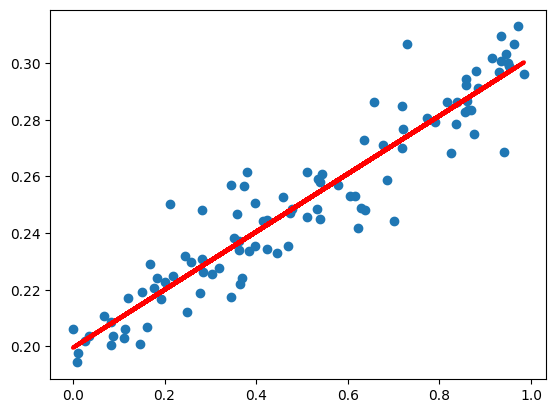

In [19]:
y_pred = model(inputs)
plt.scatter(x_data,y_data)
plt.plot(x_data,y_pred.data.numpy(),'r-',lw=3)
plt.show()